In [1]:
import os
import sys
import shutil
os.environ['TOKENIZERS_PARALLELISM'] = "False"

import torch
import pandas as pd
import numpy as np
import decord
import json
from IPython.display import display, Markdown, Latex
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
import PIL.Image
from glob import glob
from natsort import natsorted

from torch.utils.data import Dataset, DataLoader
from easydict import EasyDict as edict
import numpy as np
import json

import shared.utils as su
from utils.video import read_frames_decord
from utils.model import transform_pixel_values
from torchvision.transforms.v2 import (
    ToPILImage,
)
from models.modeling_encoders import AutoEncoder
from notebooks.eval_care_retrieval import load_model, load_data

Failed to import Qwen2_5_VLModel, Qwen2_5_VLForConditionalGeneration.


In [52]:
# Load data
dataset = 'epic'
df = load_data(dataset)
df = df.drop_duplicates(subset=['id', 'text_id']).reset_index(drop=True)

# Chiral IDs
chiral_triplet_ids = df.chiral_triplet_id.unique()

df.shape

Number of rows:  3109
Sample row: 
{
    "narration_id": "P01_11_1",
    "participant_id": "P01",
    "video_id": "P01_11",
    "narration_timestamp": "00:00:01.700",
    "start_timestamp": "00:00:01.56",
    "stop_timestamp": "00:00:02.45",
    "start_frame": 93,
    "stop_frame": 147,
    "narration": "put down plate",
    "verb": "put-down",
    "verb_class": 1,
    "noun": "na",
    "noun_class": 2,
    "all_nouns": "['plate']",
    "all_noun_classes": "[2]",
    "start_sec": 1.56,
    "stop_sec": 2.45,
    "id": "P01/videos/P01_11_1.6_2.4",
    "chiral_label": 0.0,
    "chiral_triplet_id": "ecff8160",
    "template": "put-down plate",
    "noun_value": "plate",
    "text_id": "ecff8160_0.0",
    "video_path": "/scratch/shared/beegfs/piyush/datasets/EPIC-Kitchens-100/cut_clips/P01/videos/P01_11_1.6_2.4.MP4"
}


(3108, 24)

In [53]:
embed_dirs = {
    # "Base": "/work/piyush/pretrained_checkpoints/Tarsier-7b/embs",
    # "TARA": "/work/piyush/experiments/CaRe/Tarsier-7b/final-10112025/nli_9000+ego_1000+subj_replaced-seed_42/embs"
    "Base": "/work/piyush/pretrained_checkpoints/Tarsier2-7b-0115/embs/",
    "TARA": "/work/piyush/experiments/CaRe/Tarsier2-7b-0115/covr/chiral10k-covr10k/merged_checkpoint/embs/"
}
video_feat = {}
texts_feat = {}
for model_name in embed_dirs:
    video_feat[model_name] = torch.load(f"{embed_dirs[model_name]}/video_feat-{dataset}.pt")
    texts_feat[model_name] = torch.load(f"{embed_dirs[model_name]}/texts_feat-{dataset}.pt")
len(texts_feat)

2

In [54]:
df.template.unique()

array(['put-down plate', 'turn-on tap', 'open bin', 'turn-off tap',
       'put-down cloth', 'close bin', 'close bag', 'open bag',
       'close container', 'open fridge', 'close fridge', 'put-down tray',
       'put-down spatula', 'open container', 'put-down knife',
       'put-down lid', 'put-down liquid:washing', 'put-down fork',
       'put-down sponge', 'open drawer', 'close drawer', 'open cupboard',
       'close cupboard', 'put-down spoon', 'put-down container',
       'put-down cereal', 'open box', 'put-down cup', 'put-down glass',
       'close box', 'put-down kettle', 'put-down colander',
       'put-down pan', 'put-down board:chopping', 'put-down salt',
       'open bottle', 'put-down bottle', 'put-down cutlery', 'open sauce',
       'put-down sauce', 'turn-off hob', 'put-down bowl', 'open oil',
       'close oil', 'put-down oil', 'turn-on hob', 'pick-up tray',
       'pick-up oil', 'pick-up sauce', 'pick-up spoon', 'pick-up bottle',
       'pick-up plate', 'turn-on oven', '

In [55]:
# df[df.template == "Moving [something] up"].chiral_triplet_id.iloc[0]
# df[df.template == 'someone is dressing'].chiral_triplet_id.iloc[0]
# template = 'someone is standing up from somewhere'
template = 'put-down plate'

df[df.template == template].chiral_triplet_id.iloc[0]

'ecff8160'

**With text embeddings**

torch.Size([138, 3584])
[-0.57920164  7.3147807 ]
[-0.5710999  7.3094306]
----------------------------------------------------------------------------------------------------
torch.Size([138, 3584])
[3.0109425 4.046737 ]
[ 0.8083929 -0.5204978]
----------------------------------------------------------------------------------------------------


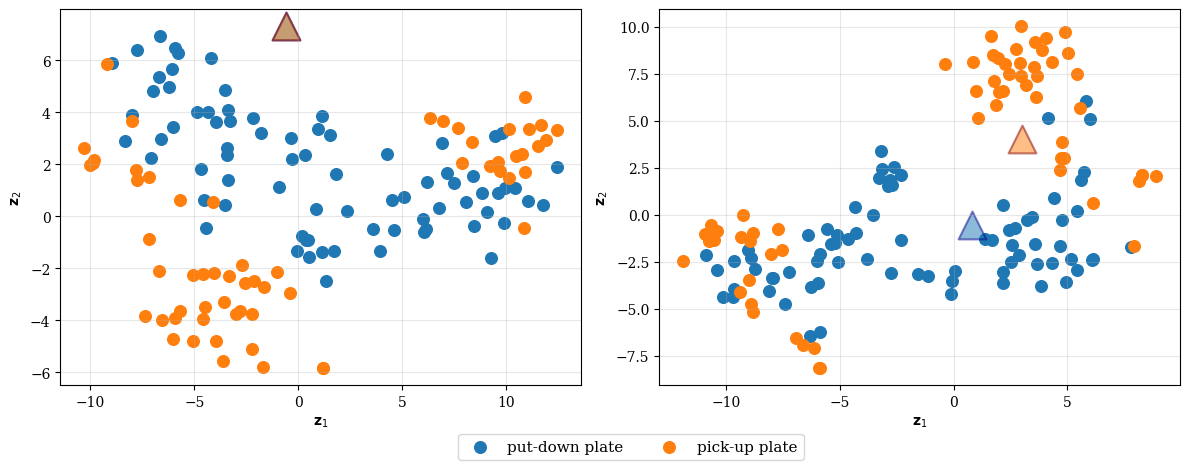

In [56]:
# Pick a chiral action
# cid = np.random.choice(chiral_triplet_ids)
# cid = '3f20f09b'
# cid = '7f9dfd30'
# cid = 'e3c2c932'
cid = 'ecff8160'

# cid = chiral_triplet_ids[15]
# cid = "b58b2f93"
text_id_neg = f"{cid}_0.0"
text_id_pos = f"{cid}_1.0"
subdf = df[df.text_id.isin([text_id_neg, text_id_pos])]
ids = subdf.id.tolist()
class_names = subdf.template.unique()

n_models = len(embed_dirs)
model_names = list(embed_dirs)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4.5))
# method = 'pca'
method = 'tsne'
save = False

handles, labels = None, None  # To store legend handles/labels

for j, ax in enumerate(axes):
    model_name = model_names[j]
    ax.grid(alpha=0.3)
    ax.set_xlabel("$\\mathbf{z}_{1}$")
    ax.set_ylabel("$\\mathbf{z}_{2}$")
    # if j == 0:
    #     ax.set_title("Base Model (Tarsier-7B)", fontsize=13)
    # else:
    #     ax.set_title("TARA (Ours)", fontsize=13)
    # ax.set_title(model_name, fontsize=13)
    zv_ = torch.stack([video_feat[model_name][k] for k in ids])
    print(zv_.shape)

    zt_pos = texts_feat[model_name][f"{cid}_1.0"]
    zt_neg = texts_feat[model_name][f"{cid}_0.0"]
    z = torch.cat([zv_, zt_pos[None], zt_neg[None]])
    tsne = su.visualize.reduce_dim(z, method=method)
    tsne_v = tsne[:-2]
    tsne_tpos = tsne[-2]
    tsne_tneg = tsne[-1]
    print(tsne_tpos)
    print(tsne_tneg)

    chiral_labels = [0.0, 1.0]
    colors = ['tab:blue', 'tab:orange']
    edgecolor = ['darkblue', 'maroon']
    for p, l in enumerate(chiral_labels):
        idx = np.where(subdf.chiral_label == l)[0]
        ax.scatter(tsne_v[idx, 0], tsne_v[idx, 1], label=class_names[p], s=70, color=colors[p])

        s = 400
        if l == 1.0:
            ax.scatter(tsne_tpos[0], tsne_tpos[1], marker='^', s=s, color=colors[p], edgecolor=edgecolor[p], alpha=0.5, linewidths=1.5)
        else:
            ax.scatter(tsne_tneg[0], tsne_tneg[1], marker='^', s=s, color=colors[p], edgecolor=edgecolor[p], alpha=0.5, linewidths=1.5)
    
    # for p, l in enumerate(class_names):
    #     idx = np.where(subdf.template == class_names[p])[0]
    #     ax.scatter(tsne_v[idx, 0], tsne_v[idx, 1], label=class_names[p], s=50)
    # ax.scatter(tsne_tpos[0], tsne_tpos[1], marker='x', s=120, color='tab:blue')
    # ax.scatter(tsne_tneg[0], tsne_tneg[1], marker='x', s=120, color='tab:orange')
    
    # Capture handles and labels from the first subplot
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    print("-" * 100)

# Annotate
# ax.annotate('Video', xy=(tsne_v[-1, 0], tsne_v[-1, 1]), 
#             xytext=(20, 10), textcoords='offset points',
#             arrowprops=dict(arrowstyle='->', color='gray'),
#             fontsize=10)
# ax.annotate('Video', xy=(tsne_v[140, 0], tsne_v[140, 1]), 
#             xytext=(20, 15), textcoords='offset points',
#             arrowprops=dict(arrowstyle='->', color='gray'),
#             fontsize=20)

# ax.annotate('Text', xy=(tsne_tpos[0], tsne_tpos[1]), 
#             xytext=(-5, -30), textcoords='offset points',
#             arrowprops=dict(arrowstyle='->', color='gray'),
#             fontsize=10)


# Create a single legend below the plots, centered, single column
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.53, 0.04), 
           ncol=2, frameon=True, fontsize=11)

plt.tight_layout()
# plt.subplots_adjust(bottom=0.25)  # Make room for the legend at the bottom
# plt.savefig("../figures/tsne-take-put-v2.pdf", bbox_inches='tight')
if save:
    plt.savefig(f"../figures/{method}-{cid}-v2.pdf", bbox_inches='tight')
plt.show()

In [57]:
# Compute quantitative measure
zt_pos.shape, zt_neg.shape, zv_.shape

idx_pos = np.where(subdf.chiral_label == 1.0)[0]
idx_neg = np.where(subdf.chiral_label == 0.0)[0]

idx_pos.shape, idx_neg.shape

((61,), (77,))

In [58]:
cosine_sim = lambda x, y: torch.nn.functional.cosine_similarity(x, y).mean()
euclid_dis = lambda x, y: torch.cdist(x.unsqueeze(0), y).mean()

dist_fn = cosine_sim
# dist_fn = euclid_dis

for j in range(2):
    model_name = model_names[j]

    zv_ = torch.stack([video_feat[model_name][k] for k in ids])
    zt_pos = texts_feat[model_name][f"{cid}_1.0"]
    zt_neg = texts_feat[model_name][f"{cid}_0.0"]
    zt_ = torch.stack([zt_pos, zt_neg])

    s_pos = (dist_fn(zt_pos, zv_[idx_pos]) - dist_fn(zt_pos, zv_[idx_neg])).item()
    s_neg = (dist_fn(zt_neg, zv_[idx_neg]) - dist_fn(zt_neg, zv_[idx_pos])).item()
    s = (s_pos + s_neg) / 2.
    print(model_name, s)

Base 0.005674511194229126
TARA 0.0927542895078659


### Old code

torch.Size([71, 3584])
torch.Size([71, 3584])


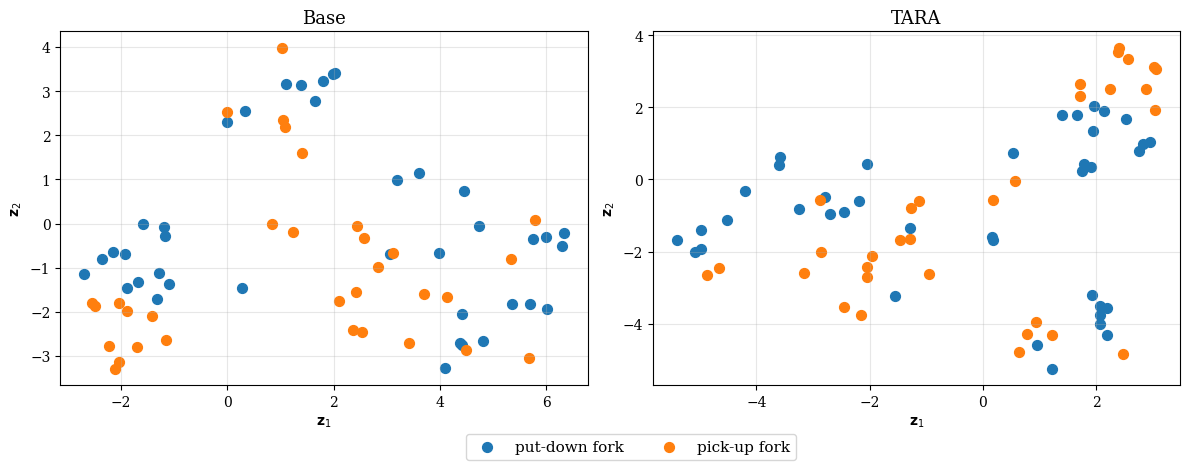

In [111]:
# Pick a chiral action
# cid = np.random.choice(chiral_triplet_ids)
cid = '3f20f09b'

# cid = chiral_triplet_ids[1]
# cid = chiral_triplet_ids[11]
# cid = "b58b2f93"
text_id_neg = f"{cid}_0.0"
text_id_pos = f"{cid}_1.0"
subdf = df[df.text_id.isin([text_id_neg, text_id_pos])]
ids = subdf.id.tolist()
class_names = subdf.template.unique()
# method = 'pca'
method = "tsne"
save = False

n_models = len(embed_dirs)
model_names = list(embed_dirs)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4.5))

handles, labels = None, None  # To store legend handles/labels

for j, ax in enumerate(axes):
    model_name = model_names[j]
    ax.grid(alpha=0.3)
    ax.set_xlabel("$\\mathbf{z}_{1}$")
    ax.set_ylabel("$\\mathbf{z}_{2}$")
    ax.set_title(model_name, fontsize=13)
    zv_ = torch.stack([video_feat[model_name][k] for k in ids])
    print(zv_.shape)
    
    tsne_ = su.visualize.reduce_dim(zv_, method=method)
    for l in class_names:
        idx = np.where(subdf.template == l)[0]
        ax.scatter(tsne_[idx, 0], tsne_[idx, 1], label=l, s=50)
    
    # Capture handles and labels from the first subplot
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

# Create a single legend below the plots, centered, single column
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.53, 0.04), 
           ncol=2, frameon=True, fontsize=11)

plt.tight_layout()
# plt.subplots_adjust(bottom=0.25)  # Make room for the legend at the bottom
# plt.savefig("../figures/tsne-take-put-v1.pdf", bbox_inches='tight')
plt.show()